# 02 — GARCH Volatility Modelling & Regime Definition
**Why GARCH?** ACF of squared returns showed significant autocorrelation → volatility clusters.
GARCH(1,1) models this. We use its **conditional volatility output** to define market regimes
(Low Vol vs High Vol) — which is statistically grounded, unlike arbitrary date splits.

**Input:** `gold_silver_revised.csv`  
**Output:** `gold_silver_garch.csv` (adds `garch_vol_au`, `garch_vol_ag`, `vol_regime_au`, `vol_regime_ag`, `period_regime`)

## Setup & Data Load

In [1]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.6 MB/s eta 0:00:00


In [2]:
from google.colab import files
files.upload()

Saving gold_silver_revised.csv to gold_silver_revised.csv


{'gold_silver_revised.csv': b'Date,gold,silver,vix,interest,usd_idx,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean\r\n03-02-2010,79.37000275,1111.400024,16.30999947,3.703000069,21.60000038,0.004546044,-0.005384076,0.004341228,0.011362473,0.001306222,-8.09E-05\r\n04-02-2010,79.91999817,1062.400024,15.34300041,3.609999895,26.07999992,0.006905614,-0.045089981,0.004521395,0.014987113,0.002022312,-0.003723115\r\n05-02-2010,80.44000244,1052.199951,14.82299995,3.546000004,26.11000061,0.006485484,-0.009647359,0.004594788,0.014458968,0.002721947,-0.003456027\r\n08-02-2010,80.30000305,1065.699951,15.07800007,3.592000008,26.51000023,-0.001741936,0.012748651,0.004577428,0.014895589,0.002662787,-0.002730514\r\n09-02-2010,79.86000061,1076.699951,15.43099976,3.632999897,26,-0.00549455,0.010268948,0.004564445,0.015091409,0.00180686,-0.001949852\r\n10-02-2010,80.02999878,1075.800049,15.30200005,3.694000006,25.39999962,0.00212644,-0.000836146,0.004226105,0.014777727,0.001701255,-0.000796224\r\n11-0

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('gold_silver_revised.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Loaded: {df.shape[0]} rows, {df.index[0].date()} → {df.index[-1].date()}")

Loaded: 4056 rows, 2010-02-03 → 2026-03-13


## 1. Fit GARCH(1,1) — Gold

In [4]:
# GARCH works better with returns scaled to percentage points
returns_au = df['au_returns'] * 100

garch_au = arch_model(returns_au, vol='Garch', p=1, q=1, dist='normal', mean='Constant')
fit_au   = garch_au.fit(disp='off')
print(fit_au.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             au_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2273.05
Distribution:                  Normal   AIC:                           4554.11
Method:            Maximum Likelihood   BIC:                           4579.34
                                        No. Observations:                 4056
Date:                Mon, Jun 01 2026   Df Residuals:                     4055
Time:                        08:19:10   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         7.0396e-03  6.201e-03      1.135      0.256 

## 2. Fit GARCH(1,1) — Silver

In [5]:
returns_ag = df['ag_returns'] * 100

garch_ag = arch_model(returns_ag, vol='Garch', p=1, q=1, dist='normal', mean='Constant')
fit_ag   = garch_ag.fit(disp='off')
print(fit_ag.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             ag_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5710.87
Distribution:                  Normal   AIC:                           11429.7
Method:            Maximum Likelihood   BIC:                           11455.0
                                        No. Observations:                 4056
Date:                Mon, Jun 01 2026   Df Residuals:                     4055
Time:                        08:19:13   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0228  1.561e-02      1.461      0.144 

## 3. Extract Conditional Volatility

In [6]:
# Conditional vol comes out in %-point units — convert back
df['garch_vol_au'] = fit_au.conditional_volatility / 100
df['garch_vol_ag'] = fit_ag.conditional_volatility / 100

print("GARCH Conditional Volatility Stats:")
print(df[['garch_vol_au','garch_vol_ag']].describe().round(6))

GARCH Conditional Volatility Stats:
       garch_vol_au  garch_vol_ag
count   4056.000000   4056.000000
mean       0.004359      0.010199
std        0.001057      0.002913
min        0.002223      0.006568
25%        0.003582      0.008430
50%        0.004157      0.009446
75%        0.005047      0.010938
max        0.009022      0.033800


## 4. GARCH vs Realized Volatility

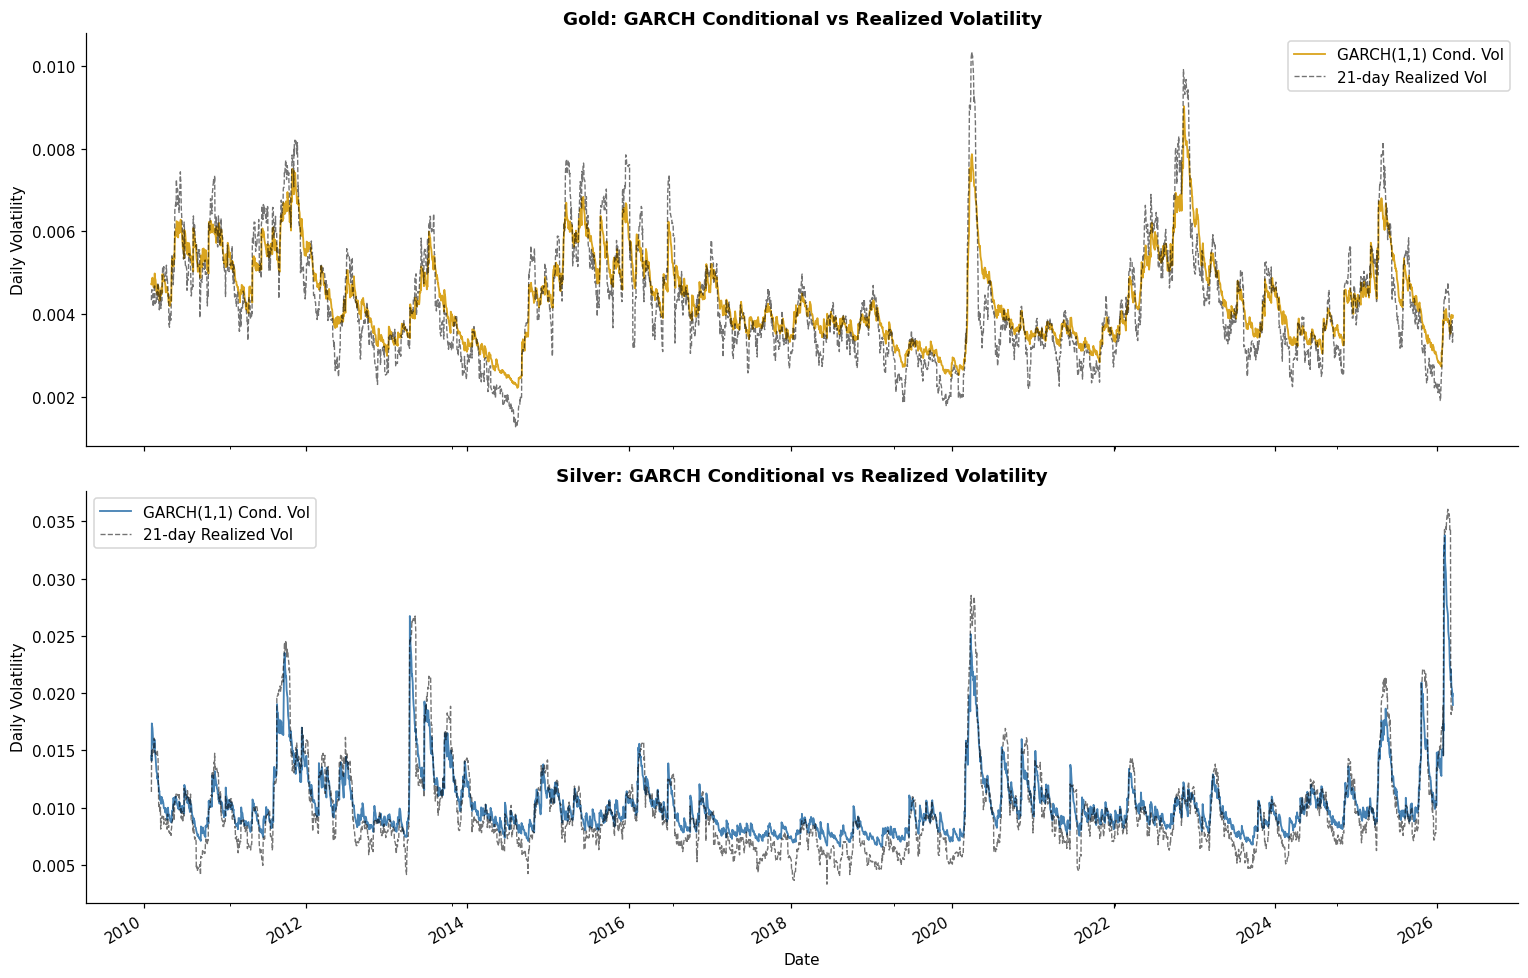

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Gold
df['garch_vol_au'].plot(ax=axes[0], color='goldenrod', linewidth=1.2, label='GARCH(1,1) Cond. Vol')
df['au_vol'].plot(ax=axes[0], color='black', linewidth=0.9, alpha=0.55, linestyle='--', label='21-day Realized Vol')
axes[0].set_title('Gold: GARCH Conditional vs Realized Volatility', fontweight='bold')
axes[0].set_ylabel('Daily Volatility')
axes[0].legend()

# Silver
df['garch_vol_ag'].plot(ax=axes[1], color='steelblue', linewidth=1.2, label='GARCH(1,1) Cond. Vol')
df['ag_vol'].plot(ax=axes[1], color='black', linewidth=0.9, alpha=0.55, linestyle='--', label='21-day Realized Vol')
axes[1].set_title('Silver: GARCH Conditional vs Realized Volatility', fontweight='bold')
axes[1].set_ylabel('Daily Volatility')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Define Volatility Regimes (Median Split)

In [8]:
# Threshold = median conditional volatility over full history
median_vol_au = df['garch_vol_au'].median()
median_vol_ag = df['garch_vol_ag'].median()

print(f"Gold  GARCH vol median: {median_vol_au:.6f}")
print(f"Silver GARCH vol median: {median_vol_ag:.6f}")

df['vol_regime_au'] = np.where(df['garch_vol_au'] >= median_vol_au, 'high_vol', 'low_vol')
df['vol_regime_ag'] = np.where(df['garch_vol_ag'] >= median_vol_ag, 'high_vol', 'low_vol')

print("\nGold Regime Distribution:")
print(df['vol_regime_au'].value_counts())
print("\nSilver Regime Distribution:")
print(df['vol_regime_ag'].value_counts())

Gold  GARCH vol median: 0.004157
Silver GARCH vol median: 0.009446

Gold Regime Distribution:
vol_regime_au
high_vol    2028
low_vol     2028
Name: count, dtype: int64

Silver Regime Distribution:
vol_regime_ag
high_vol    2028
low_vol     2028
Name: count, dtype: int64


## 6. Define Period Regimes (Pre/During/Post-COVID)

In [9]:
def get_period_regime(date):
    if date < pd.Timestamp('2020-03-01'):
        return 'pre_covid'
    elif date <= pd.Timestamp('2021-12-31'):
        return 'covid'
    else:
        return 'post_covid'

df['period_regime'] = df.index.map(get_period_regime)
print("Period Regime Distribution:")
print(df['period_regime'].value_counts())

Period Regime Distribution:
period_regime
pre_covid     2536
post_covid    1055
covid          465
Name: count, dtype: int64


## 7. Visualise Regimes on Price Chart

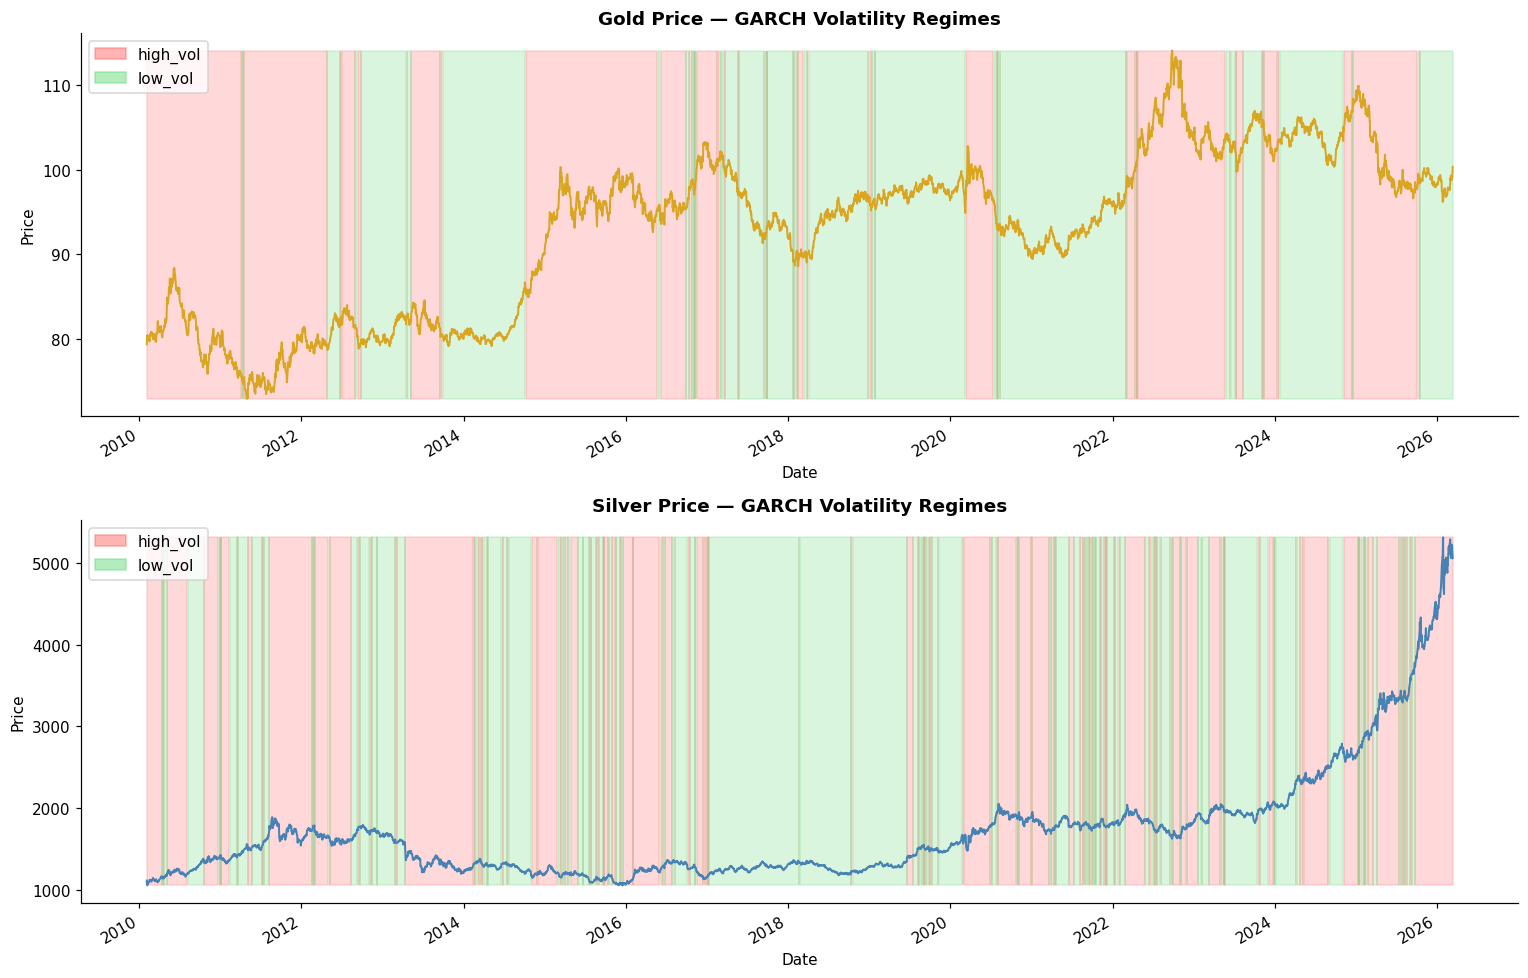

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
colors = {'high_vol': '#FF6B6B', 'low_vol': '#69DB7C'}

for regime, color in colors.items():
    mask = df['vol_regime_au'] == regime
    axes[0].fill_between(df.index, df['gold'].min(), df['gold'].max(),
                         where=mask, alpha=0.25, color=color)
df['gold'].plot(ax=axes[0], color='goldenrod', linewidth=1.3, zorder=5)
axes[0].set_title('Gold Price — GARCH Volatility Regimes', fontweight='bold')
axes[0].set_ylabel('Price')
patches = [mpatches.Patch(color=c, alpha=0.5, label=l) for l, c in colors.items()]
axes[0].legend(handles=patches, loc='upper left')

for regime, color in colors.items():
    mask = df['vol_regime_ag'] == regime
    axes[1].fill_between(df.index, df['silver'].min(), df['silver'].max(),
                         where=mask, alpha=0.25, color=color)
df['silver'].plot(ax=axes[1], color='steelblue', linewidth=1.3, zorder=5)
axes[1].set_title('Silver Price — GARCH Volatility Regimes', fontweight='bold')
axes[1].set_ylabel('Price')
axes[1].legend(handles=patches, loc='upper left')

plt.tight_layout()
plt.show()

## 8. Return Statistics by Regime

In [11]:
def regime_stats(df, return_col, regime_col, asset):
    print(f"\n{'='*55}")
    print(f"  {asset} Return Stats by {regime_col}")
    print(f"{'='*55}")
    grp = df.groupby(regime_col)[return_col]
    stats = grp.agg(['mean','std','min','max',
                     lambda x: (x > 0).mean()]).round(6)
    stats.columns = ['Mean','Std','Min','Max','% Up Days']
    print(stats.to_string())

regime_stats(df, 'au_returns', 'vol_regime_au',  'GOLD   | Vol Regime')
regime_stats(df, 'au_returns', 'period_regime',  'GOLD   | Period Regime')
regime_stats(df, 'ag_returns', 'vol_regime_ag',  'SILVER | Vol Regime')
regime_stats(df, 'ag_returns', 'period_regime',  'SILVER | Period Regime')


  GOLD   | Vol Regime Return Stats by vol_regime_au
                   Mean       Std       Min       Max  % Up Days
vol_regime_au                                                   
high_vol       0.000039  0.005250 -0.023988  0.020320   0.497041
low_vol        0.000079  0.003511 -0.016140  0.016019   0.506410

  GOLD   | Period Regime Return Stats by period_regime
                   Mean       Std       Min       Max  % Up Days
period_regime                                                   
covid         -0.000055  0.004007 -0.016262  0.015786   0.468817
post_covid     0.000045  0.004695 -0.021394  0.016389   0.513744
pre_covid      0.000085  0.004448 -0.023988  0.020320   0.502760

  SILVER | Vol Regime Return Stats by vol_regime_ag
                   Mean       Std       Min       Max  % Up Days
vol_regime_ag                                                   
high_vol       0.000392  0.012334 -0.120657  0.059054   0.530079
low_vol        0.000353  0.008500 -0.047386  0.045568   0.

## 9. Save Enriched Dataset

In [12]:
df.to_csv('gold_silver_garch.csv')
print("Saved: gold_silver_garch.csv")
print(f"Columns now: {df.columns.tolist()}")
print(f"Shape: {df.shape}")

Saved: gold_silver_garch.csv
Columns now: ['gold', 'silver', 'vix', 'interest', 'usd_idx', 'au_returns', 'ag_returns', 'au_vol', 'ag_vol', 'au_mean', 'ag_mean', 'garch_vol_au', 'garch_vol_ag', 'vol_regime_au', 'vol_regime_ag', 'period_regime']
Shape: (4056, 16)


In [13]:
files.download("gold_silver_garch.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary
- GARCH(1,1) successfully captures **volatility clustering** in both metals
- We now have **two regime views**:
  - `vol_regime` (Low/High based on GARCH conditional vol) — statistically grounded
  - `period_regime` (Pre/During/Post-COVID) — interpretable narrative context
- These regimes will be used consistently across **all** model notebooks
- GARCH conditional volatility will also be added as a **predictive feature**

**→ Next: Notebook 03 — Feature Engineering & Classification Target**